# Sensitivity of MPC to Forecast Accuracy — Direct σ Noise Study

Tests the FCR-D sequential auction pipeline with **direct σ noise**
(Gaussian random walk, Eq. 4 from Langtry et al. 2024).

σ is the per-step standard deviation of the random walk noise,
applied directly without any data-derived scaling.

Two main result plots:
- **Early auction**: % of perfect performance vs nRMSE of early-auction input variables
- **Late auction**: % of perfect performance vs nRMSE of late-auction input variables

## 1 — Imports and configuration

In [6]:
import warnings
from pathlib import Path
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Objective, Constraint,
    NonNegativeReals, Reals, Binary, minimize, value, SolverFactory,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

DATA_DIR  = Path('../data/data_out')
DATA_FILE = DATA_DIR / 'combined_2025_with_frequency.csv'

N_ECS = 10; B_MAX_EC = 100.0; S_MAX_EC = 200.0
ETA_MEAN = 0.95; ETA_SIGMA = 0.0; T_SUSTAIN = 0.5
P_MIN = 100.0; SOC_INIT_FRAC = 0.5; SOLVER = 'appsi_highs'
P_B_CHANCE = 0.6; SCALE_MU = 1.0; SCALE_SIGMA = 1.0

P_BAR_AGG = N_ECS * B_MAX_EC; S_AGG = N_ECS * S_MAX_EC

TEST_DATE = datetime.date(2025, 5, 10)

# ── Direct σ values to test ─────────────────────────────────────────────
# σ is the per-step std of the Gaussian random walk (Eq. 4, Langtry 2024).
# Different variables have different natural scales, so σ values are
# chosen to produce a useful range of nRMSE across all variable types.
SIGMA_VALUES = [0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
RANDOM_SEED = 42

print(f'Portfolio: {P_BAR_AGG:.0f} kW / {S_AGG:.0f} kWh')
print(f'Test date: {TEST_DATE}')
print(f'Sigma values: {SIGMA_VALUES}')

Portfolio: 1000 kW / 2000 kWh
Test date: 2025-05-10
Sigma values: [0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]


## 2 — Synthetic EC portfolio

In [7]:
rng = np.random.default_rng(42)
EC_LIST = []
for i in range(N_ECS):
    base = 'b' if rng.random() < P_B_CHANCE else 's'
    scale = -1.0
    while scale <= 0:
        scale = float(rng.normal(SCALE_MU, SCALE_SIGMA))
    eta_e = ETA_MEAN
    EC_LIST.append({'id': f'ec{i:02d}', 'base': base, 'scale': scale,
                    'b_max': B_MAX_EC, 's_max': S_MAX_EC, 'eta': eta_e})
EC_IDS = [ec['id'] for ec in EC_LIST]
EC_BY_ID = {ec['id']: ec for ec in EC_LIST}
n_b = sum(1 for e in EC_LIST if e['base'] == 'b')
print(f'{N_ECS} ECs: {n_b} b-type, {N_ECS-n_b} s-type')

10 ECs: 4 b-type, 6 s-type


## 3 — Load data

In [8]:
df_raw = pd.read_csv(DATA_FILE, parse_dates=['hour_utc'])
df_raw['spot_dkk']       = df_raw['spot_exkl_vat_ore_kwh'] / 100.0
df_raw['buy_price_dkk']  = df_raw['buy_price_inkl_vat_ore_kwh'] / 100.0
df_raw['sell_price_dkk'] = df_raw['sell_price_inkl_vat_ore_kwh'] / 100.0
df_raw['buy_markup_dkk'] = df_raw['buy_price_dkk'] - df_raw['spot_dkk']
df_raw['sell_markup_dkk']= df_raw['sell_price_dkk'] - df_raw['spot_dkk']
df_raw['fcrd_up_early_dkk'] = df_raw['price_ore_kwh_fcr_d_upp__d_1_early'].fillna(0).clip(lower=0) / 100.0
df_raw['fcrd_up_late_dkk']  = df_raw['price_ore_kwh_fcr_d_upp__d_1_late' ].fillna(0).clip(lower=0) / 100.0
df_raw['fcrd_dn_early_dkk'] = df_raw['price_ore_kwh_fcr_d_ned__d_1_early'].fillna(0).clip(lower=0) / 100.0
df_raw['fcrd_dn_late_dkk']  = df_raw['price_ore_kwh_fcr_d_ned__d_1_late' ].fillna(0).clip(lower=0) / 100.0
df_raw['y_act_up'] = df_raw['y_act_fcrd_up'].fillna(0).clip(0, 1)
df_raw['y_act_dn'] = df_raw['y_act_fcrd_down'].fillna(0).clip(0, 1)
df = df_raw[df_raw['data_quality_flag'] == 0].copy()
df['date'] = df['hour_utc'].dt.date
df_b = df[df['ec_id'] == 'b'].set_index('hour_utc').sort_index()
df_s = df[df['ec_id'] == 's'].set_index('hour_utc').sort_index()
all_dates = sorted(set(df_b.index.date))
print(f'EC b: {len(df_b)} hours  |  EC s: {len(df_s)} hours')
print(f'Test date {TEST_DATE} available: {TEST_DATE in all_dates}')

EC b: 8745 hours  |  EC s: 8745 hours
Test date 2025-05-10 available: True


## 4 — Model builders (from NB06)

In [9]:
def build_early(day, fcrd=True):
    m = ConcreteModel()
    T = list(range(1, 25))
    m.E = Set(initialize=EC_IDS)
    m.T = Set(initialize=T)

    m.D  = Param(m.E, m.T, initialize={(e,t): day['D' ][e][t-1] for e in EC_IDS for t in T})
    m.PV = Param(m.E, m.T, initialize={(e,t): day['PV'][e][t-1] for e in EC_IDS for t in T})
    m.b_max = Param(m.E, initialize={e: EC_BY_ID[e]['b_max'] for e in EC_IDS})
    m.s_max = Param(m.E, initialize={e: EC_BY_ID[e]['s_max'] for e in EC_IDS})
    m.eta   = Param(m.E, initialize={e: EC_BY_ID[e]['eta'  ] for e in EC_IDS})
    m.buy   = Param(m.T, initialize={t: day['buy_price' ][t-1] for t in T})
    m.sell  = Param(m.T, initialize={t: day['sell_price'][t-1] for t in T})
    if fcrd:
        m.lam_up   = Param(m.T, initialize={t: day['fcrd_up_price'][t-1] for t in T})
        m.lam_dn   = Param(m.T, initialize={t: day['fcrd_dn_price'][t-1] for t in T})
        m.y_act_up = Param(m.T, initialize={t: day['y_act_up'     ][t-1] for t in T})
        m.y_act_dn = Param(m.T, initialize={t: day['y_act_dn'     ][t-1] for t in T})

    m.p_im  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_ex  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_net = Var(m.E, m.T, domain=Reals)
    m.b_ch  = Var(m.E, m.T, domain=NonNegativeReals)
    m.b_dis = Var(m.E, m.T, domain=NonNegativeReals)
    m.soc   = Var(m.E, m.T, domain=NonNegativeReals)
    if fcrd:
        m.p_res_up = Var(m.E, m.T, domain=NonNegativeReals)
        m.p_res_dn = Var(m.E, m.T, domain=NonNegativeReals)
        m.p_act_up = Var(m.E, m.T, domain=NonNegativeReals)
        m.p_act_dn = Var(m.E, m.T, domain=NonNegativeReals)
        m.z_up = Var(m.T, domain=Binary)
        m.z_dn = Var(m.T, domain=Binary)

    if fcrd:
        m.obj = Objective(sense=minimize, expr=sum(
              m.buy[t]  * (sum(m.p_im[e,t] for e in m.E) - sum(m.p_act_dn[e,t] for e in m.E))
            - m.sell[t] * (sum(m.p_ex[e,t] for e in m.E) - sum(m.p_act_up[e,t] for e in m.E))
            - m.lam_up[t] * sum(m.p_res_up[e,t] for e in m.E)
            - m.lam_dn[t] * sum(m.p_res_dn[e,t] for e in m.E)
            for t in m.T))
    else:
        m.obj = Objective(sense=minimize, expr=sum(
            m.buy[t]*m.p_im[e,t] - m.sell[t]*m.p_ex[e,t]
            for e in m.E for t in m.T))

    m.c_m1b = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] - m.p_im[e,t] + m.p_ex[e,t] == 0)

    def _c2i(m,e,t):
        rhs = m.p_net[e,t] + m.PV[e,t] - m.D[e,t] - m.b_ch[e,t] + m.b_dis[e,t]
        if fcrd: rhs = rhs - m.p_act_dn[e,t] + m.p_act_up[e,t]
        return rhs == 0
    m.c_c2i = Constraint(m.E, m.T, rule=_c2i)

    if fcrd:
        m.c_c3b_up = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.p_act_up[e,t] == m.y_act_up[t] * m.p_res_up[e,t])
        m.c_c3b_dn = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.p_act_dn[e,t] == m.y_act_dn[t] * m.p_res_dn[e,t])

    def _m2j(m,e,t):
        if t == 1: return Constraint.Skip
        gain  = m.b_ch[e,t]  + (m.p_act_dn[e,t] if fcrd else 0)
        drain = m.b_dis[e,t] + (m.p_act_up[e,t] if fcrd else 0)
        return m.soc[e,t] == m.soc[e,t-1] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2j = Constraint(m.E, m.T, rule=_m2j)

    def _m2k(m,e):
        gain  = m.b_ch[e,1]  + (m.p_act_dn[e,1] if fcrd else 0)
        drain = m.b_dis[e,1] + (m.p_act_up[e,1] if fcrd else 0)
        return m.soc[e,1] == SOC_INIT_FRAC*m.s_max[e] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2k = Constraint(m.E, rule=_m2k)

    m.c_c1l = Constraint(m.E,
        rule=lambda m,e: m.soc[e,24] == SOC_INIT_FRAC*m.s_max[e])

    if fcrd:
        m.c_m13_up = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.soc[e,t] >= (T_SUSTAIN/m.eta[e])*m.p_res_up[e,t])
        m.c_m13_dn = Constraint(m.E, m.T,
            rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= T_SUSTAIN*m.eta[e]*m.p_res_dn[e,t])
        m.c_c1m = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.b_ch[e,t]  + m.p_res_dn[e,t] <= m.b_max[e])
        m.c_c3c = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.b_dis[e,t] + m.p_res_up[e,t] <= m.b_max[e])
    else:
        m.c_bch  = Constraint(m.E, m.T, rule=lambda m,e,t: m.b_ch[e,t]  <= m.b_max[e])
        m.c_bdis = Constraint(m.E, m.T, rule=lambda m,e,t: m.b_dis[e,t] <= m.b_max[e])

    m.c_soc_max = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] <= m.s_max[e])

    if fcrd:
        m.c_c3d_up = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.soc[e,t] >= m.p_res_up[e,t])
        m.c_c3d_dn = Constraint(m.E, m.T,
            rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= m.p_res_dn[e,t])
        m.c_m1_up_lo = Constraint(m.T,
            rule=lambda m,t: P_MIN*m.z_up[t] <= sum(m.p_res_up[e,t] for e in m.E))
        m.c_m1_up_hi = Constraint(m.T,
            rule=lambda m,t: sum(m.p_res_up[e,t] for e in m.E) <= P_BAR_AGG*m.z_up[t])
        m.c_m1_dn_lo = Constraint(m.T,
            rule=lambda m,t: P_MIN*m.z_dn[t] <= sum(m.p_res_dn[e,t] for e in m.E))
        m.c_m1_dn_hi = Constraint(m.T,
            rule=lambda m,t: sum(m.p_res_dn[e,t] for e in m.E) <= P_BAR_AGG*m.z_dn[t])
    return m


def solve_model(m):
    return SolverFactory(SOLVER).solve(m, tee=False)

In [10]:
def extract_early_accepted(m_early):
    acc_up, acc_dn = {}, {}
    for e in EC_IDS:
        for t in range(1, 25):
            acc_up[(e,t)] = max(0.0, value(m_early.p_res_up[e,t]))
            acc_dn[(e,t)] = max(0.0, value(m_early.p_res_dn[e,t]))
    return acc_up, acc_dn


def build_late(day_late, early_acc_up, early_acc_dn,
               early_clearing_up, early_clearing_dn):
    m = ConcreteModel()
    T = list(range(1, 25))
    m.E = Set(initialize=EC_IDS)
    m.T = Set(initialize=T)

    m.D  = Param(m.E, m.T, initialize={(e,t): day_late['D' ][e][t-1] for e in EC_IDS for t in T})
    m.PV = Param(m.E, m.T, initialize={(e,t): day_late['PV'][e][t-1] for e in EC_IDS for t in T})
    m.b_max = Param(m.E, initialize={e: EC_BY_ID[e]['b_max'] for e in EC_IDS})
    m.s_max = Param(m.E, initialize={e: EC_BY_ID[e]['s_max'] for e in EC_IDS})
    m.eta   = Param(m.E, initialize={e: EC_BY_ID[e]['eta'  ] for e in EC_IDS})
    m.buy   = Param(m.T, initialize={t: day_late['buy_price' ][t-1] for t in T})
    m.sell  = Param(m.T, initialize={t: day_late['sell_price'][t-1] for t in T})

    m.lam_up_late  = Param(m.T, initialize={t: day_late['fcrd_up_price_late'][t-1] for t in T})
    m.lam_dn_late  = Param(m.T, initialize={t: day_late['fcrd_dn_price_late'][t-1] for t in T})
    m.lam_up_early = Param(m.T, initialize={t: early_clearing_up[t-1] for t in T})
    m.lam_dn_early = Param(m.T, initialize={t: early_clearing_dn[t-1] for t in T})

    m.lam_up_bb = Param(m.T, initialize={
        t: max(early_clearing_up[t-1], day_late['fcrd_up_price_late'][t-1]) for t in T})
    m.lam_dn_bb = Param(m.T, initialize={
        t: max(early_clearing_dn[t-1], day_late['fcrd_dn_price_late'][t-1]) for t in T})

    m.p_acc_up = Param(m.E, m.T, initialize=early_acc_up)
    m.p_acc_dn = Param(m.E, m.T, initialize=early_acc_dn)

    m.y_act_up = Param(m.T, initialize={t: day_late['y_act_up'][t-1] for t in T})
    m.y_act_dn = Param(m.T, initialize={t: day_late['y_act_dn'][t-1] for t in T})

    m.p_im  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_ex  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_net = Var(m.E, m.T, domain=Reals)
    m.b_ch  = Var(m.E, m.T, domain=NonNegativeReals)
    m.b_dis = Var(m.E, m.T, domain=NonNegativeReals)
    m.soc   = Var(m.E, m.T, domain=NonNegativeReals)

    m.c_up = Var(m.E, m.T, domain=NonNegativeReals)
    m.c_dn = Var(m.E, m.T, domain=NonNegativeReals)
    m.a_up = Var(m.E, m.T, domain=NonNegativeReals)
    m.a_dn = Var(m.E, m.T, domain=NonNegativeReals)

    m.p_res_up = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_res_dn = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_act_up = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_act_dn = Var(m.E, m.T, domain=NonNegativeReals)

    m.z_up = Var(m.T, domain=Binary)
    m.z_dn = Var(m.T, domain=Binary)
    m.w_up = Var(m.T, domain=Binary)
    m.w_dn = Var(m.T, domain=Binary)

    m.c_l1_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_res_up[e,t] == m.p_acc_up[e,t] - m.c_up[e,t] + m.a_up[e,t])
    m.c_l1_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_res_dn[e,t] == m.p_acc_dn[e,t] - m.c_dn[e,t] + m.a_dn[e,t])

    m.c_l2_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_up[e,t] <= m.p_acc_up[e,t])
    m.c_l2_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_dn[e,t] <= m.p_acc_dn[e,t])

    m.c_no_mix_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_up[e,t] <= m.p_acc_up[e,t] * (1 - m.w_up[t]))
    m.c_no_mix_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_dn[e,t] <= m.p_acc_dn[e,t] * (1 - m.w_dn[t]))

    m.obj = Objective(sense=minimize, expr=sum(
          m.buy[t]  * (sum(m.p_im[e,t] for e in m.E) - sum(m.p_act_dn[e,t] for e in m.E))
        - m.sell[t] * (sum(m.p_ex[e,t] for e in m.E) - sum(m.p_act_up[e,t] for e in m.E))
        - m.lam_up_early[t] * sum(m.p_acc_up[e,t] for e in m.E)
        - m.lam_dn_early[t] * sum(m.p_acc_dn[e,t] for e in m.E)
        + m.lam_up_bb[t] * sum(m.c_up[e,t] for e in m.E)
        + m.lam_dn_bb[t] * sum(m.c_dn[e,t] for e in m.E)
        - m.lam_up_late[t] * sum(m.a_up[e,t] for e in m.E)
        - m.lam_dn_late[t] * sum(m.a_dn[e,t] for e in m.E)
        for t in m.T))

    m.c_m1b = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] - m.p_im[e,t] + m.p_ex[e,t] == 0)

    m.c_c2i = Constraint(m.E, m.T,
        rule=lambda m,e,t: (m.p_net[e,t] + m.PV[e,t] - m.D[e,t]
            - m.b_ch[e,t] - m.p_act_dn[e,t]
            + m.b_dis[e,t] + m.p_act_up[e,t]) == 0)

    m.c_c3b_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_act_up[e,t] == m.y_act_up[t]*m.p_res_up[e,t])
    m.c_c3b_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_act_dn[e,t] == m.y_act_dn[t]*m.p_res_dn[e,t])

    def _m2j(m,e,t):
        if t == 1: return Constraint.Skip
        gain  = m.b_ch[e,t]  + m.p_act_dn[e,t]
        drain = m.b_dis[e,t] + m.p_act_up[e,t]
        return m.soc[e,t] == m.soc[e,t-1] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2j = Constraint(m.E, m.T, rule=_m2j)

    def _m2k(m,e):
        gain  = m.b_ch[e,1] + m.p_act_dn[e,1]
        drain = m.b_dis[e,1] + m.p_act_up[e,1]
        return m.soc[e,1] == SOC_INIT_FRAC*m.s_max[e] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2k = Constraint(m.E, rule=_m2k)

    m.c_c1l = Constraint(m.E,
        rule=lambda m,e: m.soc[e,24] == SOC_INIT_FRAC*m.s_max[e])

    m.c_m13_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] >= (T_SUSTAIN/m.eta[e])*m.p_res_up[e,t])
    m.c_m13_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= T_SUSTAIN*m.eta[e]*m.p_res_dn[e,t])

    m.c_c1m = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_ch[e,t]  + m.p_res_dn[e,t] <= m.b_max[e])
    m.c_c3c = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_dis[e,t] + m.p_res_up[e,t] <= m.b_max[e])

    m.c_soc_max = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] <= m.s_max[e])
    m.c_c3d_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] >= m.p_res_up[e,t])
    m.c_c3d_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= m.p_res_dn[e,t])

    m.c_l5_up_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.w_up[t] <= sum(m.a_up[e,t] for e in m.E))
    m.c_l5_up_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.a_up[e,t] for e in m.E) <= P_BAR_AGG*m.w_up[t])
    m.c_l5_dn_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.w_dn[t] <= sum(m.a_dn[e,t] for e in m.E))
    m.c_l5_dn_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.a_dn[e,t] for e in m.E) <= P_BAR_AGG*m.w_dn[t])

    m.c_l6_up_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.z_up[t] <= sum(m.p_res_up[e,t] for e in m.E))
    m.c_l6_up_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.p_res_up[e,t] for e in m.E) <= P_BAR_AGG*m.z_up[t])
    m.c_l6_dn_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.z_dn[t] <= sum(m.p_res_dn[e,t] for e in m.E))
    m.c_l6_dn_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.p_res_dn[e,t] for e in m.E) <= P_BAR_AGG*m.z_dn[t])

    return m

## 5 — Noise generation (direct σ, no data-derived scaling)

Gaussian random walk noise per Eq. 4 of Langtry et al. (2024):

$$f^v_{GRW}[t, \tau] = v_{t+\tau} + \sum_{j=1}^{\tau} w^\sigma_j, \quad w^\sigma_j \sim \mathcal{N}(0, \sigma^2)$$

σ is the **per-step standard deviation** of the random walk, applied
directly in the natural units of each variable. No empirical σ̂ reference.

In [11]:
def generate_random_walk_noise(horizon, sigma, rng):
    """Gaussian random walk: cumulative sum of N(0, σ²) increments."""
    if sigma <= 0:
        return np.zeros(horizon)
    return np.cumsum(rng.normal(0, sigma, horizon))


def add_noise_direct(true_vec, horizon, sl_start, sl_end, sigma, rng, scale=1.0):
    """Add random walk noise with per-step std = sigma * scale.
    No empirical reference — sigma is used directly."""
    if sigma <= 0:
        return true_vec.copy()
    noise = generate_random_walk_noise(horizon, sigma * scale, rng)
    return np.maximum(0, true_vec + noise[sl_start:sl_end])


def compute_nrmse(forecast, true, mean_level):
    if mean_level == 0:
        return np.nan
    rmse = np.sqrt(np.mean((forecast - true) ** 2))
    return rmse / mean_level


def get_true_day(date):
    day_b = df_b[df_b.index.date == date].reset_index(drop=True)
    day_s = df_s[df_s.index.date == date].reset_index(drop=True)
    if len(day_b) != 24 or len(day_s) != 24:
        return None
    D_true, PV_true = {}, {}
    for ec in EC_LIST:
        src = day_b if ec['base'] == 'b' else day_s
        D_true[ec['id']]  = src['consumption'].values * ec['scale']
        PV_true[ec['id']] = src['pv_production_kwh'].values * ec['scale']
    return {
        'D': D_true, 'PV': PV_true,
        'buy_price': day_b['buy_price_dkk'].values,
        'sell_price': day_b['sell_price_dkk'].values,
        'spot_dkk': day_b['spot_dkk'].values,
        'buy_markup': day_b['buy_markup_dkk'].values,
        'sell_markup': day_b['sell_markup_dkk'].values,
        'fcrd_up_early': day_b['fcrd_up_early_dkk'].values,
        'fcrd_dn_early': day_b['fcrd_dn_early_dkk'].values,
        'fcrd_up_late': day_b['fcrd_up_late_dkk'].values,
        'fcrd_dn_late': day_b['fcrd_dn_late_dkk'].values,
        'y_act_up': day_b['y_act_up'].values,
        'y_act_dn': day_b['y_act_dn'].values,
        'date': date,
    }

print('Noise utilities defined (direct σ, no empirical reference).')

Noise utilities defined (direct σ, no empirical reference).


## 6 — Early forecast (direct σ)

Noise structure:
- **Load**: independent noise per EC (σ_load per step, scaled by EC scale factor)
- **PV**: one shared noise draw (σ_pv per step, scaled by EC scale factor)
- **Spot price**: single forecast (σ_spot per step)
- **FCR-D early prices**: single forecast each (σ_fcrd per step)
- **Activation fractions**: perfect foresight

In [12]:
def make_early_forecast(true_day, sigma_config, rng):
    """Early auction forecast with direct σ noise (48h horizon, extract [24:48])."""
    D_fc, PV_fc = {}, {}
    sigma_load = sigma_config.get('load', 0)
    sigma_pv   = sigma_config.get('pv', 0)

    # Load: independent noise per EC
    for ec in EC_LIST:
        D_fc[ec['id']] = add_noise_direct(
            true_day['D'][ec['id']], 48, 24, 48,
            sigma_load, rng, ec['scale'])

    # PV: ONE shared noise draw (all buildings share weather)
    if sigma_pv and sigma_pv > 0:
        pv_noise_48 = generate_random_walk_noise(48, sigma_pv, rng)
        pv_noise_24 = pv_noise_48[24:48]
        for ec in EC_LIST:
            PV_fc[ec['id']] = np.maximum(0, true_day['PV'][ec['id']] + pv_noise_24 * ec['scale'])
    else:
        for ec in EC_LIST:
            PV_fc[ec['id']] = true_day['PV'][ec['id']].copy()

    # Spot price
    sigma_spot = sigma_config.get('spot', 0)
    if sigma_spot and sigma_spot > 0:
        spot_fc = add_noise_direct(true_day['spot_dkk'], 48, 24, 48, sigma_spot, rng)
        buy_fc  = np.maximum(0, spot_fc + true_day['buy_markup'])
        sell_fc = np.maximum(0, spot_fc + true_day['sell_markup'])
    else:
        buy_fc  = true_day['buy_price'].copy()
        sell_fc = true_day['sell_price'].copy()

    # FCR-D early prices
    sigma_fue = sigma_config.get('fcrd_up_early', 0)
    fcrd_up_early_fc = add_noise_direct(true_day['fcrd_up_early'], 48, 24, 48, sigma_fue, rng)

    sigma_fde = sigma_config.get('fcrd_dn_early', 0)
    fcrd_dn_early_fc = add_noise_direct(true_day['fcrd_dn_early'], 48, 24, 48, sigma_fde, rng)

    return {
        'date': true_day['date'],
        'D': D_fc, 'PV': PV_fc,
        'buy_price': buy_fc, 'sell_price': sell_fc,
        'fcrd_up_price': fcrd_up_early_fc,
        'fcrd_dn_price': fcrd_dn_early_fc,
        'y_act_up': true_day['y_act_up'],
        'y_act_dn': true_day['y_act_dn'],
    }

print('Early forecast defined (direct σ).')

Early forecast defined (direct σ).


## 7 — Early bid

In [13]:
def run_early_bid(early_forecast):
    m_early = build_early(early_forecast, fcrd=True)
    solve_model(m_early)
    acc_up, acc_dn = extract_early_accepted(m_early)
    return m_early, acc_up, acc_dn

print('Early bid defined.')

Early bid defined.


## 8 — Late forecast (direct σ, 30h horizon)

Same noise structure as early, but shorter horizon (30h → less accumulated noise).
Spot prices are known perfectly (DA market publishes at 13:00).
FCR-D early prices are known (early auction already cleared).

In [14]:
def make_late_forecast(true_day, sigma_config, rng):
    """Late auction forecast with direct σ noise (30h horizon, extract [6:30])."""
    D_fc, PV_fc = {}, {}
    sigma_load = sigma_config.get('load', 0)
    sigma_pv   = sigma_config.get('pv', 0)

    # Load: independent noise per EC
    for ec in EC_LIST:
        D_fc[ec['id']] = add_noise_direct(
            true_day['D'][ec['id']], 30, 6, 30,
            sigma_load, rng, ec['scale'])

    # PV: ONE shared noise draw (shorter late horizon)
    if sigma_pv and sigma_pv > 0:
        pv_noise_30 = generate_random_walk_noise(30, sigma_pv, rng)
        pv_noise_24 = pv_noise_30[6:30]
        for ec in EC_LIST:
            PV_fc[ec['id']] = np.maximum(0, true_day['PV'][ec['id']] + pv_noise_24 * ec['scale'])
    else:
        for ec in EC_LIST:
            PV_fc[ec['id']] = true_day['PV'][ec['id']].copy()

    # FCR-D late prices
    sigma_ful = sigma_config.get('fcrd_up_late', 0)
    fcrd_up_late_fc = add_noise_direct(true_day['fcrd_up_late'], 30, 6, 30, sigma_ful, rng)

    sigma_fdl = sigma_config.get('fcrd_dn_late', 0)
    fcrd_dn_late_fc = add_noise_direct(true_day['fcrd_dn_late'], 30, 6, 30, sigma_fdl, rng)

    return {
        'date': true_day['date'],
        'D': D_fc, 'PV': PV_fc,
        'buy_price':  true_day['buy_price'],   # TRUE — DA spot known
        'sell_price': true_day['sell_price'],
        'fcrd_up_price_late':  fcrd_up_late_fc,
        'fcrd_dn_price_late':  fcrd_dn_late_fc,
        'fcrd_up_price_early': true_day['fcrd_up_early'],  # TRUE — already cleared
        'fcrd_dn_price_early': true_day['fcrd_dn_early'],
        'y_act_up': true_day['y_act_up'],
        'y_act_dn': true_day['y_act_dn'],
    }

print('Late forecast defined (direct σ).')

Late forecast defined (direct σ).


## 9 — Late bid

In [15]:
def run_late_bid(late_forecast, early_acc_up, early_acc_dn, true_day):
    clr_up = true_day['fcrd_up_early']
    clr_dn = true_day['fcrd_dn_early']
    m_late = build_late(late_forecast, early_acc_up, early_acc_dn, clr_up, clr_dn)
    solve_model(m_late)
    return m_late

print('Late bid defined.')

Late bid defined.


## 10 — Simulate delivery day

In [16]:
def simulate_day(m_late, true_day):
    true_buy   = true_day['buy_price']
    true_sell  = true_day['sell_price']
    true_fcrd_up_early = true_day['fcrd_up_early']
    true_fcrd_dn_early = true_day['fcrd_dn_early']
    true_fcrd_up_late  = true_day['fcrd_up_late']
    true_fcrd_dn_late  = true_day['fcrd_dn_late']
    true_y_act_up = true_day['y_act_up']
    true_y_act_dn = true_day['y_act_dn']

    no_bat_cost = 0.0
    for h in range(24):
        D_agg  = sum(true_day['D'][e][h]  for e in EC_IDS)
        PV_agg = sum(true_day['PV'][e][h] for e in EC_IDS)
        no_bat_cost += (true_buy[h] * max(0, D_agg - PV_agg)
                      - true_sell[h] * max(0, PV_agg - D_agg))

    actual_arb_cost = 0.0
    actual_fcrd_up_net = 0.0
    actual_fcrd_dn_net = 0.0

    for t in range(1, 25):
        h = t - 1
        res_up = sum(value(m_late.p_res_up[e,t]) for e in EC_IDS)
        res_dn = sum(value(m_late.p_res_dn[e,t]) for e in EC_IDS)
        acc_up = sum(value(m_late.p_acc_up[e,t]) for e in EC_IDS)
        acc_dn = sum(value(m_late.p_acc_dn[e,t]) for e in EC_IDS)
        c_up   = sum(value(m_late.c_up[e,t]) for e in EC_IDS)
        c_dn   = sum(value(m_late.c_dn[e,t]) for e in EC_IDS)
        a_up   = sum(value(m_late.a_up[e,t]) for e in EC_IDS)
        a_dn   = sum(value(m_late.a_dn[e,t]) for e in EC_IDS)

        act_up = true_y_act_up[h] * res_up
        act_dn = true_y_act_dn[h] * res_dn

        actual_p_im, actual_p_ex = 0.0, 0.0
        for e in EC_IDS:
            b_ch_e  = value(m_late.b_ch[e,t])
            b_dis_e = value(m_late.b_dis[e,t])
            act_up_e = true_y_act_up[h] * value(m_late.p_res_up[e,t])
            act_dn_e = true_y_act_dn[h] * value(m_late.p_res_dn[e,t])
            p_net_e = true_day['D'][e][h] - true_day['PV'][e][h] + b_ch_e + act_dn_e - b_dis_e - act_up_e
            actual_p_im += max(0,  p_net_e)
            actual_p_ex += max(0, -p_net_e)

        actual_arb_cost += (true_buy[h] * (actual_p_im - act_dn)
                          - true_sell[h] * (actual_p_ex - act_up))

        rev_early_up = true_fcrd_up_early[h] * acc_up
        rev_early_dn = true_fcrd_dn_early[h] * acc_dn
        bb_up = max(true_fcrd_up_early[h], true_fcrd_up_late[h])
        bb_dn = max(true_fcrd_dn_early[h], true_fcrd_dn_late[h])
        actual_fcrd_up_net += rev_early_up - bb_up * c_up + true_fcrd_up_late[h] * a_up
        actual_fcrd_dn_net += rev_early_dn - bb_dn * c_dn + true_fcrd_dn_late[h] * a_dn

    total_value = (no_bat_cost - actual_arb_cost) + actual_fcrd_up_net + actual_fcrd_dn_net
    return {
        'no_bat_cost': no_bat_cost, 'arb_cost': actual_arb_cost,
        'arb_saving': no_bat_cost - actual_arb_cost,
        'fcrd_up_net': actual_fcrd_up_net, 'fcrd_dn_net': actual_fcrd_dn_net,
        'total_value': total_value,
    }

print('Delivery simulation defined.')

Delivery simulation defined.


## 11 — Full pipeline with nRMSE tracking (direct σ)

Runs early → late → delivery with direct σ noise.
Computes nRMSE separately for early-auction and late-auction input variables.

In [17]:
# Variable keys for the noise config
ALL_VAR_KEYS = ['load', 'pv', 'spot', 'fcrd_up_early', 'fcrd_dn_early', 'fcrd_up_late', 'fcrd_dn_late']

# Which nRMSE keys belong to each auction stage
EARLY_NRMSE_KEYS = ['load_early', 'pv_early', 'spot', 'fcrd_up_early', 'fcrd_dn_early']
LATE_NRMSE_KEYS  = ['load_late', 'pv_late', 'fcrd_up_late', 'fcrd_dn_late']


def run_pipeline(date, sigma_config, seed):
    true_day = get_true_day(date)
    if true_day is None:
        return None

    rng = np.random.default_rng(seed)

    # Step 1 + 2: Early
    early_fc = make_early_forecast(true_day, sigma_config, rng)
    m_early, acc_up, acc_dn = run_early_bid(early_fc)

    # Step 3 + 4: Late
    late_fc = make_late_forecast(true_day, sigma_config, rng)
    m_late = run_late_bid(late_fc, acc_up, acc_dn, true_day)

    # Step 5: Delivery
    result = simulate_day(m_late, true_day)
    result['date'] = date

    # ── Compute nRMSE for each variable ─────────────────────────────────
    D_true_agg  = np.array([sum(true_day['D'][e][h]  for e in EC_IDS) for h in range(24)])
    PV_true_agg = np.array([sum(true_day['PV'][e][h] for e in EC_IDS) for h in range(24)])
    D_early_agg = np.array([sum(early_fc['D'][e][h]  for e in EC_IDS) for h in range(24)])
    PV_early_agg= np.array([sum(early_fc['PV'][e][h] for e in EC_IDS) for h in range(24)])
    D_late_agg  = np.array([sum(late_fc['D'][e][h]   for e in EC_IDS) for h in range(24)])
    PV_late_agg = np.array([sum(late_fc['PV'][e][h]  for e in EC_IDS) for h in range(24)])

    nrmse = {}
    nrmse['load_early'] = compute_nrmse(D_early_agg, D_true_agg, max(D_true_agg.mean(), 1e-6))
    nrmse['load_late']  = compute_nrmse(D_late_agg, D_true_agg, max(D_true_agg.mean(), 1e-6))
    nrmse['pv_early']   = compute_nrmse(PV_early_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nrmse['pv_late']    = compute_nrmse(PV_late_agg, PV_true_agg, max(PV_true_agg.mean(), 1e-6))
    nrmse['spot']       = compute_nrmse(early_fc['buy_price'], true_day['buy_price'],
                                         max(true_day['buy_price'].mean(), 1e-6))
    nrmse['fcrd_up_early'] = compute_nrmse(early_fc['fcrd_up_price'], true_day['fcrd_up_early'],
                                            max(true_day['fcrd_up_early'].mean(), 1e-6))
    nrmse['fcrd_dn_early'] = compute_nrmse(early_fc['fcrd_dn_price'], true_day['fcrd_dn_early'],
                                            max(true_day['fcrd_dn_early'].mean(), 1e-6))
    nrmse['fcrd_up_late']  = compute_nrmse(late_fc['fcrd_up_price_late'], true_day['fcrd_up_late'],
                                            max(true_day['fcrd_up_late'].mean(), 1e-6))
    nrmse['fcrd_dn_late']  = compute_nrmse(late_fc['fcrd_dn_price_late'], true_day['fcrd_dn_late'],
                                            max(true_day['fcrd_dn_late'].mean(), 1e-6))
    result['nrmse'] = nrmse

    # Aggregate nRMSE by auction stage
    result['nrmse_early_avg'] = np.mean([nrmse[k] for k in EARLY_NRMSE_KEYS])
    result['nrmse_late_avg']  = np.mean([nrmse[k] for k in LATE_NRMSE_KEYS])

    return result

print('Full pipeline defined (direct σ).')

Full pipeline defined (direct σ).


## 12 — Perfect-foresight baseline

In [18]:
sigma_zero = {k: 0.0 for k in ALL_VAR_KEYS}
baseline = run_pipeline(TEST_DATE, sigma_zero, RANDOM_SEED)
baseline_revenue = baseline['total_value']

print(f'Perfect-foresight baseline — {TEST_DATE}')
print('=' * 60)
print(f'  No-battery cost:   {baseline["no_bat_cost"]:>10.2f} DKK')
print(f'  Arb saving:        {baseline["arb_saving"]:>10.2f} DKK')
print(f'  FCR-D Up net:      {baseline["fcrd_up_net"]:>10.2f} DKK')
print(f'  FCR-D Dn net:      {baseline["fcrd_dn_net"]:>10.2f} DKK')
print(f'  Total value:       {baseline["total_value"]:>10.2f} DKK')
print('=' * 60)

Perfect-foresight baseline — 2025-05-10
  No-battery cost:      3293.77 DKK
  Arb saving:           1654.02 DKK
  FCR-D Up net:         1940.47 DKK
  FCR-D Dn net:          297.99 DKK
  Total value:          3892.48 DKK


## 13 — Noise sensitivity sweep (direct σ)

Vary σ from 0 to 0.5 (per-step random walk std).
Same σ applied to all variables simultaneously,
then one-at-a-time for each variable type.

**Note:** Since variables have different natural scales,
the same σ produces vastly different nRMSE for load (kW scale)
vs. prices (DKK/kWh scale). This is expected — the nRMSE plots
in Sections 14–15 normalise this away.

In [19]:
VAR_LABELS = {
    'load': 'Load', 'pv': 'PV generation', 'spot': 'Spot price',
    'fcrd_up_early': 'FCR-D Up early', 'fcrd_dn_early': 'FCR-D Dn early',
    'fcrd_up_late': 'FCR-D Up late', 'fcrd_dn_late': 'FCR-D Dn late',
}

# ── All variables simultaneously ────────────────────────────────────────
print('All variables simultaneously...')
results_all = []
for sigma in SIGMA_VALUES:
    print(f'  σ = {sigma:.3f} ...', end=' ')
    sc = {k: sigma for k in ALL_VAR_KEYS}
    r = run_pipeline(TEST_DATE, sc, RANDOM_SEED)
    r['sigma'] = sigma
    r['rev_norm'] = r['total_value'] / baseline_revenue if baseline_revenue else np.nan
    results_all.append(r)
    print(f'value={r["total_value"]:.2f} DKK ({r["rev_norm"]:.1%})')
df_all = pd.DataFrame(results_all)

# ── One-at-a-time ───────────────────────────────────────────────────────
results_oaat = {var: [] for var in ALL_VAR_KEYS}
for var in ALL_VAR_KEYS:
    print(f'\n{VAR_LABELS[var]}...')
    for sigma in SIGMA_VALUES:
        sc = {v: 0.0 for v in ALL_VAR_KEYS}
        sc[var] = sigma
        r = run_pipeline(TEST_DATE, sc, RANDOM_SEED)
        r['sigma'] = sigma
        r['rev_norm'] = r['total_value'] / baseline_revenue if baseline_revenue else np.nan
        results_oaat[var].append(r)
        print(f'  σ={sigma:.3f}  value={r["total_value"]:>10.2f} DKK  ({r["rev_norm"]:.1%})')

df_oaat = {var: pd.DataFrame(results_oaat[var]) for var in ALL_VAR_KEYS}
print('\nSweep complete.')

All variables simultaneously...
  σ = 0.000 ... value=3892.48 DKK (100.0%)
  σ = 0.005 ... value=3831.46 DKK (98.4%)
  σ = 0.010 ... value=3800.71 DKK (97.6%)
  σ = 0.020 ... value=3356.84 DKK (86.2%)
  σ = 0.050 ... value=2221.58 DKK (57.1%)
  σ = 0.100 ... value=2079.81 DKK (53.4%)
  σ = 0.200 ... value=1931.16 DKK (49.6%)
  σ = 0.500 ... value=1262.43 DKK (32.4%)

Load...
  σ=0.000  value=   3892.48 DKK  (100.0%)
  σ=0.005  value=   3891.30 DKK  (100.0%)
  σ=0.010  value=   3890.20 DKK  (99.9%)
  σ=0.020  value=   3888.05 DKK  (99.9%)
  σ=0.050  value=   3880.92 DKK  (99.7%)
  σ=0.100  value=   3869.05 DKK  (99.4%)
  σ=0.200  value=   3844.42 DKK  (98.8%)
  σ=0.500  value=   3780.35 DKK  (97.1%)

PV generation...
  σ=0.000  value=   3892.48 DKK  (100.0%)
  σ=0.005  value=   3892.17 DKK  (100.0%)
  σ=0.010  value=   3891.89 DKK  (100.0%)
  σ=0.020  value=   3891.35 DKK  (100.0%)
  σ=0.050  value=   3889.76 DKK  (99.9%)
  σ=0.100  value=   3886.99 DKK  (99.9%)
  σ=0.200  value=   3881

## 14 — Plot 1: Revenue vs σ

Overall operational performance (% of perfect foresight) as σ varies.
Analogous to Fig. 10 in Langtry et al., but with σ on the x-axis.

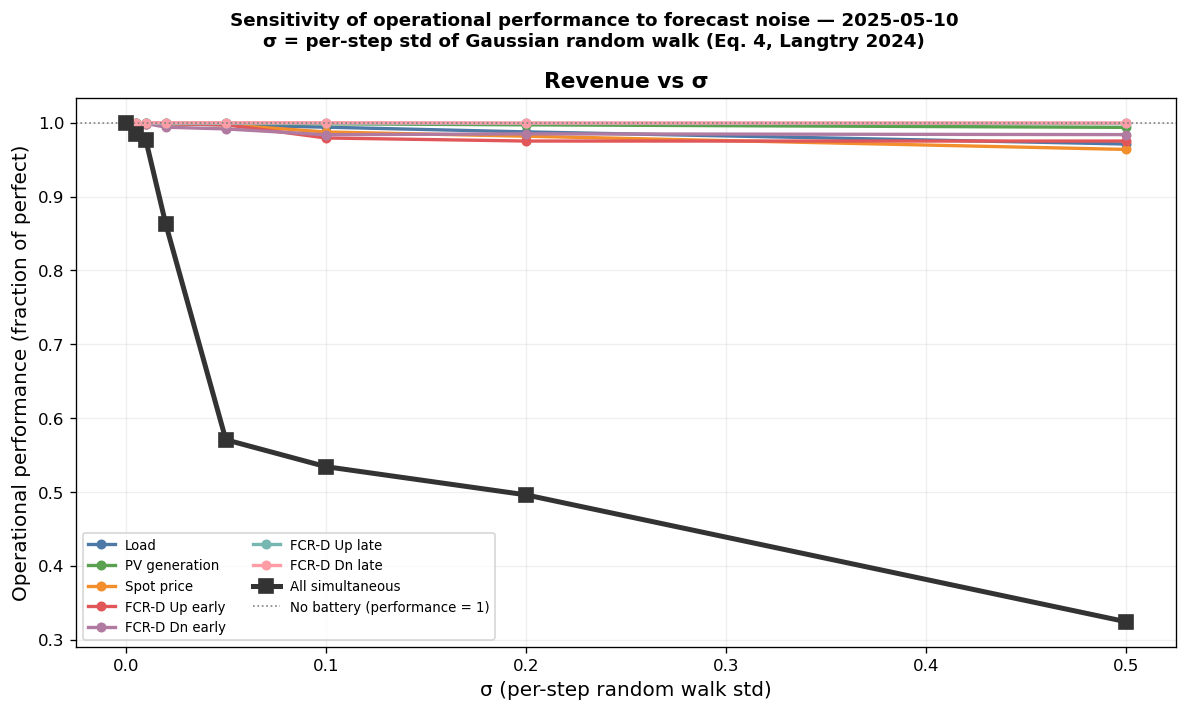

In [20]:
COLORS = {
    'load': '#4E79A7', 'pv': '#59A14F', 'spot': '#F28E2B',
    'fcrd_up_early': '#E15759', 'fcrd_dn_early': '#B07AA1',
    'fcrd_up_late': '#76B7B2', 'fcrd_dn_late': '#FF9DA7',
}

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    f'Sensitivity of operational performance to forecast noise — {TEST_DATE}\n'
    f'σ = per-step std of Gaussian random walk (Eq. 4, Langtry 2024)',
    fontsize=11, fontweight='bold')

for var in ALL_VAR_KEYS:
    d = df_oaat[var]
    ax.plot(d['sigma'], d['rev_norm'], marker='o', lw=2, ms=5,
            color=COLORS[var], label=VAR_LABELS[var])

ax.plot(df_all['sigma'], df_all['rev_norm'], marker='s', lw=3, ms=8,
        color='#333333', label='All simultaneous', zorder=10)

ax.axhline(1.0, color='gray', ls=':', lw=1, label='No battery (performance = 1)')
ax.set_xlabel('σ (per-step random walk std)', fontsize=12)
ax.set_ylabel('Operational performance (fraction of perfect)', fontsize=12)
ax.set_title('Revenue vs σ', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 15 — Plot 2: Early auction — Performance vs nRMSE of early-stage variables

The x-axis is the **average nRMSE of variables fed into the early auction model**:
load (early), PV (early), spot price, FCR-D up early price, FCR-D dn early price.

The y-axis is the total operational performance (% of perfect foresight),
reflecting the full pipeline outcome but plotted against early-stage forecast quality.

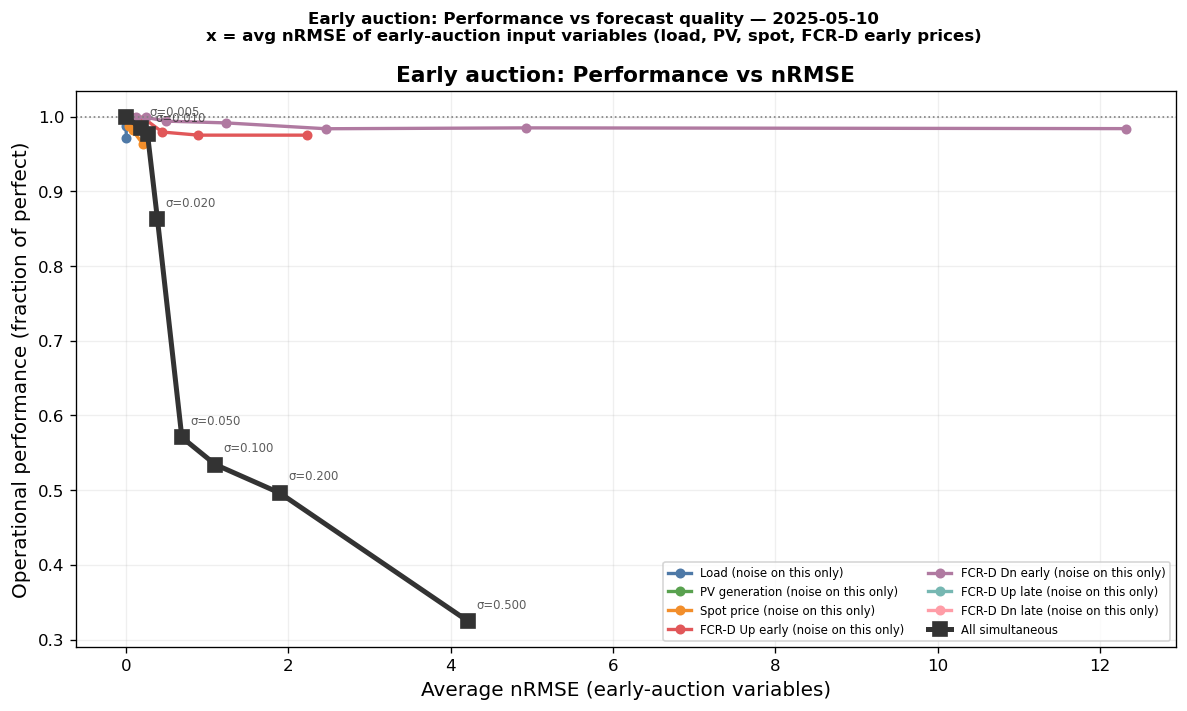

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    f'Early auction: Performance vs forecast quality — {TEST_DATE}\n'
    f'x = avg nRMSE of early-auction input variables (load, PV, spot, FCR-D early prices)',
    fontsize=10, fontweight='bold')

# One-at-a-time curves
for var in ALL_VAR_KEYS:
    data = results_oaat[var]
    # Use nRMSE of early variables as x-axis
    nrmses_early = [r['nrmse_early_avg'] for r in data]
    rev_norms = [r['rev_norm'] for r in data]
    ax.plot(nrmses_early, rev_norms, marker='o', lw=2, ms=5,
            color=COLORS[var], label=f'{VAR_LABELS[var]} (noise on this only)')

# All simultaneous
nrmses_early_all = [r['nrmse_early_avg'] for r in results_all]
rev_norms_all = [r['rev_norm'] for r in results_all]
ax.plot(nrmses_early_all, rev_norms_all, marker='s', lw=3, ms=8,
        color='#333333', label='All simultaneous', zorder=10)

# Annotate sigma values on the "all" curve
for r in results_all:
    if r['sigma'] > 0:
        ax.annotate(f'σ={r["sigma"]:.3f}',
                    (r['nrmse_early_avg'], r['rev_norm']),
                    textcoords='offset points', xytext=(5, 8),
                    fontsize=7, color='#333333', alpha=0.8)

ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_xlabel('Average nRMSE (early-auction variables)', fontsize=12)
ax.set_ylabel('Operational performance (fraction of perfect)', fontsize=12)
ax.set_title('Early auction: Performance vs nRMSE', fontsize=13, fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='best')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 16 — Plot 3: Late auction — Performance vs nRMSE of late-stage variables

The x-axis is the **average nRMSE of variables fed into the late auction model**:
load (late), PV (late), FCR-D up late price, FCR-D dn late price.

Spot price and FCR-D early prices are known perfectly at late GCT
and do not contribute to late-stage forecast error.

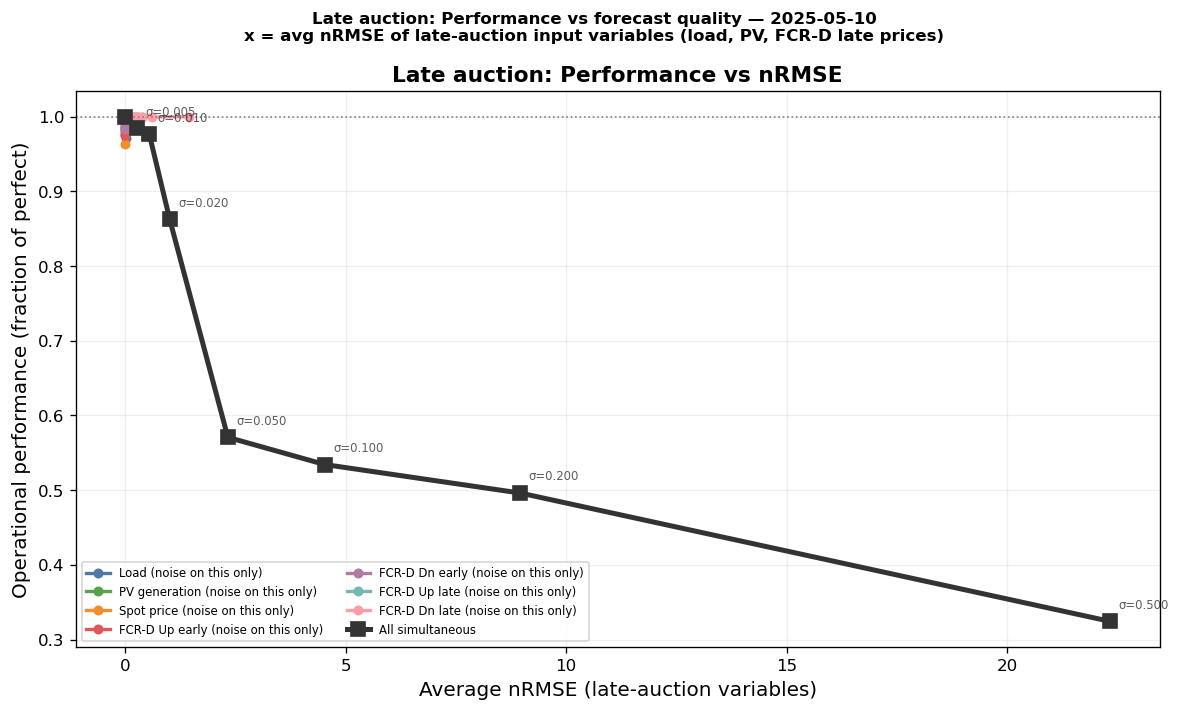

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    f'Late auction: Performance vs forecast quality — {TEST_DATE}\n'
    f'x = avg nRMSE of late-auction input variables (load, PV, FCR-D late prices)',
    fontsize=10, fontweight='bold')

# One-at-a-time curves
for var in ALL_VAR_KEYS:
    data = results_oaat[var]
    nrmses_late = [r['nrmse_late_avg'] for r in data]
    rev_norms = [r['rev_norm'] for r in data]
    ax.plot(nrmses_late, rev_norms, marker='o', lw=2, ms=5,
            color=COLORS[var], label=f'{VAR_LABELS[var]} (noise on this only)')

# All simultaneous
nrmses_late_all = [r['nrmse_late_avg'] for r in results_all]
rev_norms_all = [r['rev_norm'] for r in results_all]
ax.plot(nrmses_late_all, rev_norms_all, marker='s', lw=3, ms=8,
        color='#333333', label='All simultaneous', zorder=10)

# Annotate sigma values on the "all" curve
for r in results_all:
    if r['sigma'] > 0:
        ax.annotate(f'σ={r["sigma"]:.3f}',
                    (r['nrmse_late_avg'], r['rev_norm']),
                    textcoords='offset points', xytext=(5, 8),
                    fontsize=7, color='#333333', alpha=0.8)

ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_xlabel('Average nRMSE (late-auction variables)', fontsize=12)
ax.set_ylabel('Operational performance (fraction of perfect)', fontsize=12)
ax.set_title('Late auction: Performance vs nRMSE', fontsize=13, fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='best')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 17 — Combined figure: σ plot + Early nRMSE + Late nRMSE

Side-by-side view of all three sensitivity perspectives.

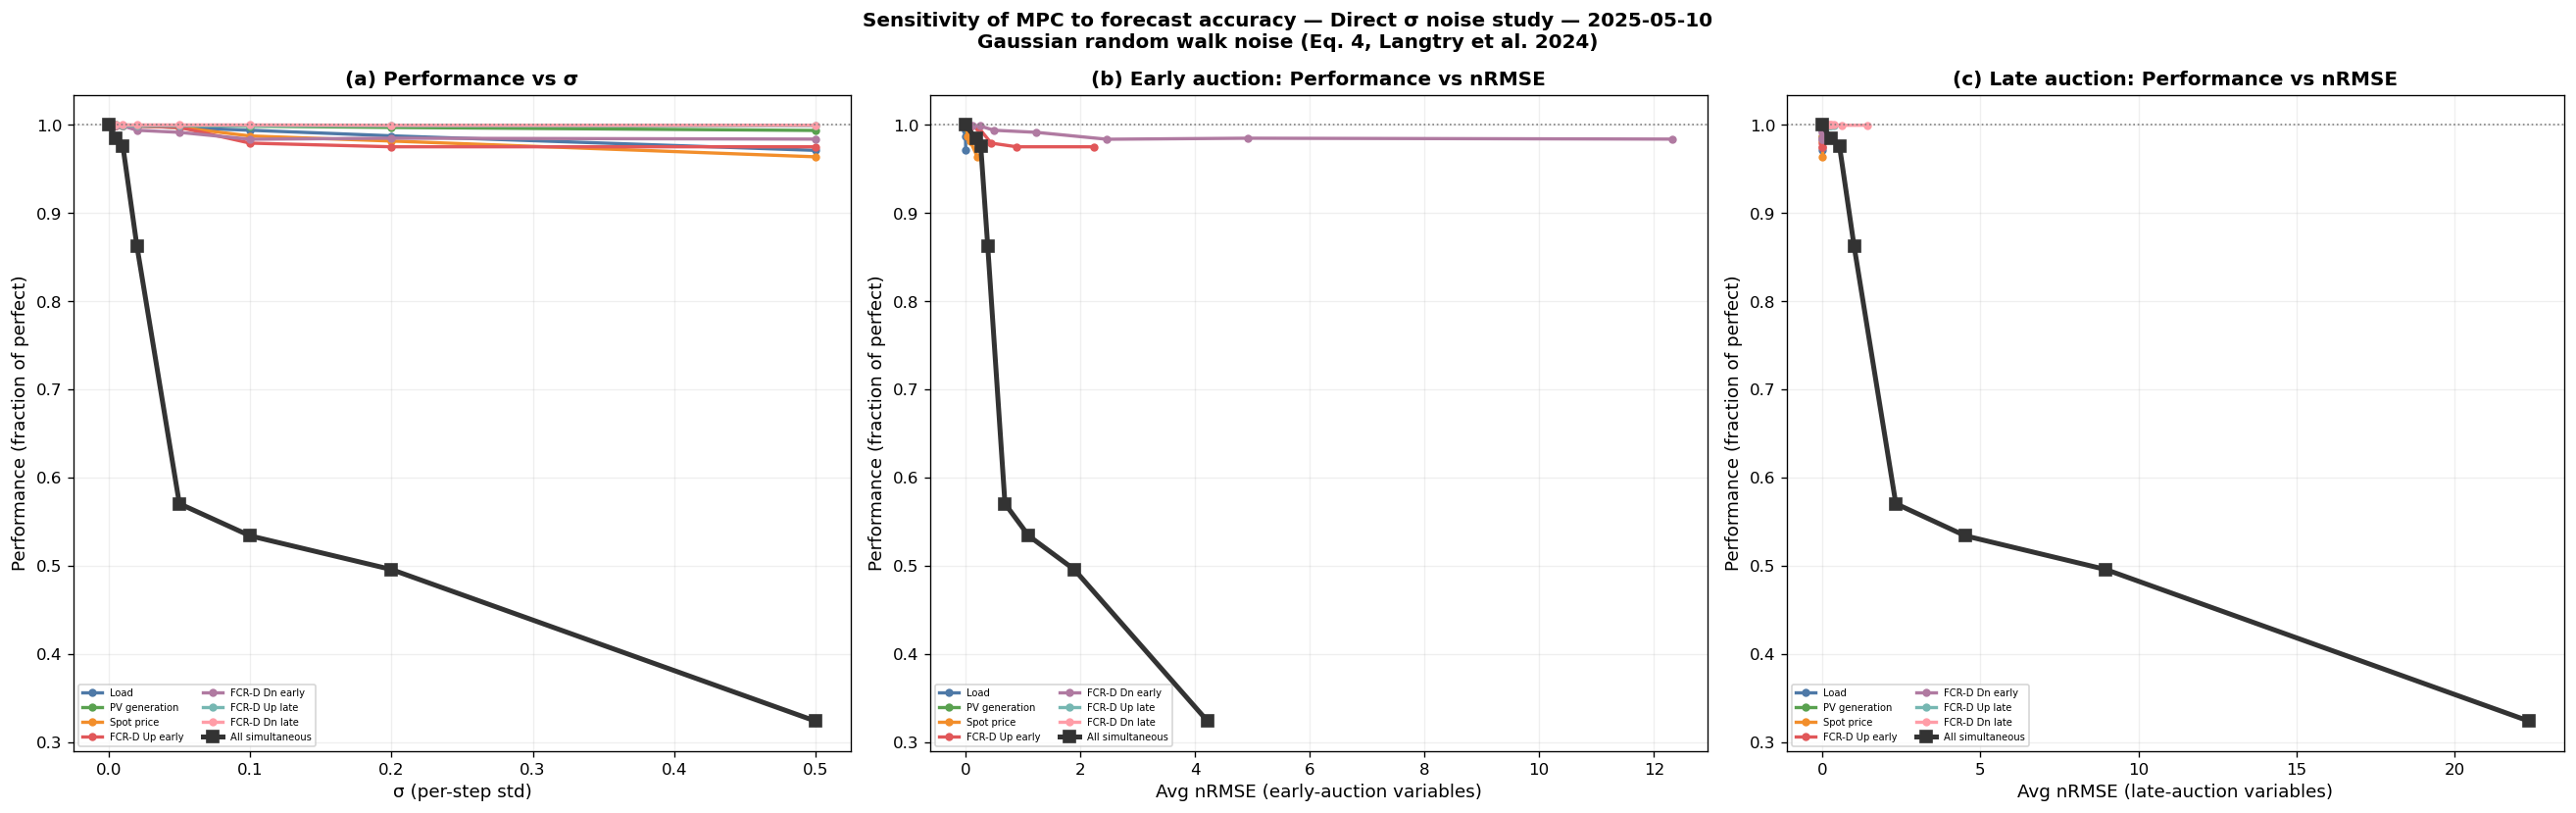

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    f'Sensitivity of MPC to forecast accuracy — Direct σ noise study — {TEST_DATE}\n'
    f'Gaussian random walk noise (Eq. 4, Langtry et al. 2024)',
    fontsize=12, fontweight='bold')

# ── Panel 1: Revenue vs σ ─────────────────────────────────────────────────
ax = axes[0]
for var in ALL_VAR_KEYS:
    d = df_oaat[var]
    ax.plot(d['sigma'], d['rev_norm'], marker='o', lw=2, ms=4,
            color=COLORS[var], label=VAR_LABELS[var])
ax.plot(df_all['sigma'], df_all['rev_norm'], marker='s', lw=3, ms=7,
        color='#333333', label='All simultaneous', zorder=10)
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_xlabel('σ (per-step std)', fontsize=11)
ax.set_ylabel('Performance (fraction of perfect)', fontsize=11)
ax.set_title('(a) Performance vs σ', fontsize=12, fontweight='bold')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.2)

# ── Panel 2: Early auction nRMSE ──────────────────────────────────────────
ax = axes[1]
for var in ALL_VAR_KEYS:
    data = results_oaat[var]
    ax.plot([r['nrmse_early_avg'] for r in data], [r['rev_norm'] for r in data],
            marker='o', lw=2, ms=4, color=COLORS[var], label=VAR_LABELS[var])
ax.plot([r['nrmse_early_avg'] for r in results_all],
        [r['rev_norm'] for r in results_all],
        marker='s', lw=3, ms=7, color='#333333', label='All simultaneous', zorder=10)
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_xlabel('Avg nRMSE (early-auction variables)', fontsize=11)
ax.set_ylabel('Performance (fraction of perfect)', fontsize=11)
ax.set_title('(b) Early auction: Performance vs nRMSE', fontsize=12, fontweight='bold')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.2)

# ── Panel 3: Late auction nRMSE ───────────────────────────────────────────
ax = axes[2]
for var in ALL_VAR_KEYS:
    data = results_oaat[var]
    ax.plot([r['nrmse_late_avg'] for r in data], [r['rev_norm'] for r in data],
            marker='o', lw=2, ms=4, color=COLORS[var], label=VAR_LABELS[var])
ax.plot([r['nrmse_late_avg'] for r in results_all],
        [r['rev_norm'] for r in results_all],
        marker='s', lw=3, ms=7, color='#333333', label='All simultaneous', zorder=10)
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_xlabel('Avg nRMSE (late-auction variables)', fontsize=11)
ax.set_ylabel('Performance (fraction of perfect)', fontsize=11)
ax.set_title('(c) Late auction: Performance vs nRMSE', fontsize=12, fontweight='bold')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 18 — Per-variable nRMSE breakdown

Shows the nRMSE achieved by each variable at each σ level.
Useful for understanding which variables are most affected by
a given noise level, and how the early vs late groupings differ.

In [24]:
print(f'Per-variable nRMSE at each σ — All variables noised simultaneously')
print('=' * 120)
header = f'{"σ":>8s}'
for k in EARLY_NRMSE_KEYS + LATE_NRMSE_KEYS:
    header += f'  {k:>14s}'
header += f'  {"early_avg":>10s}  {"late_avg":>10s}  {"rev%":>8s}'
print(header)
print('-' * 120)

for r in results_all:
    line = f'{r["sigma"]:>8.3f}'
    for k in EARLY_NRMSE_KEYS + LATE_NRMSE_KEYS:
        line += f'  {r["nrmse"].get(k, 0):>14.4f}'
    line += f'  {r["nrmse_early_avg"]:>10.4f}  {r["nrmse_late_avg"]:>10.4f}'
    line += f'  {r["rev_norm"]:>8.1%}'
    print(line)

print('-' * 120)
print()
print('Note: load/PV nRMSE is small because σ (in DKK/kWh units) is tiny')
print('relative to load/PV scales (kW). Price variables are most affected.')
print('This mirrors the paper\'s finding that MPC is most sensitive to')
print('price forecast accuracy (electricity price and carbon intensity).')

Per-variable nRMSE at each σ — All variables noised simultaneously
       σ      load_early        pv_early            spot   fcrd_up_early   fcrd_dn_early       load_late         pv_late    fcrd_up_late    fcrd_dn_late   early_avg    late_avg      rev%
------------------------------------------------------------------------------------------------------------------------
   0.000          0.0000          0.0000          0.0000          0.0000          0.0000          0.0000          0.0000          0.0000          0.0000      0.0000      0.0000    100.0%
   0.005          0.0003          0.0037          0.0280          0.2435          0.6559          0.0006          0.0040          0.2639          0.8443      0.1863      0.2782     98.4%
   0.010          0.0006          0.0074          0.0534          0.4842          0.7897          0.0013          0.0081          0.5092          1.6760      0.2670      0.5486     97.6%
   0.020          0.0012          0.0148          0.0984        